# Initialization Scale Ablation: Figure 4 Left

This notebook plots the excess validation loss for the minimal architecture under different query initialization scales. It uses the `ICLR-Fig1` W&B tag, the same sweep that produced the minimal-model staged-learning runs.


In [1]:
from analysis.utils import (
    REPORT_BLUE,
    REPORT_GREEN,
    REPORT_LINEWIDTH,
    REPORT_RED,
    REPORT_YELLOW,
    differing_config,
    fetch_runs,
    get_runs_data,
    style_report_axis,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


SAVE_FIGURES = False


def output_path(name):
    return f"analysis/figures/{name}" if SAVE_FIGURES else None


In [2]:
runs = fetch_runs(tags_any=["ICLR-Fig1"])
df = get_runs_data(runs, metrics=["val_loss", "teacher_val_loss"])
differing_config(df.drop(columns=["cfg.teacher.span_lengths"], errors="ignore"))


,_run_id,_run_name,cfg.ngrams.bigram.query_init_scale,cfg.ngrams.bigram.value_init_scale,cfg.ngrams.trigram.query_init_scale,cfg.ngrams.trigram.value_init_scale,cfg.ngrams.unigram.query_init_scale,cfg.ngrams.unigram.value_init_scale,cfg.student.query_init_scale,cfg.student.value_init_scale
0,dayi1xj5,fearless-capybara-1686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,hhfk9daj,hearty-puddle-1679,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.000000e+00,0.0
2,i0a1de0a,apricot-paper-1676,1.000000e-09,0.0,1.000000e-09,0.0,1.000000e-09,0.0,1.000000e-09,0.0
3,iai8ang2,decent-gorge-1677,1.000000e-06,0.0,1.000000e-06,0.0,1.000000e-06,0.0,1.000000e-06,0.0
4,xy9noxwc,cool-eon-1677,1.000000e-03,0.0,1.000000e-03,0.0,1.000000e-03,0.0,1.000000e-03,0.0


## Figure 4 Left: Excess Loss By Query Initialization

Subtracting the teacher loss makes the staged optimization behavior comparable across runs.


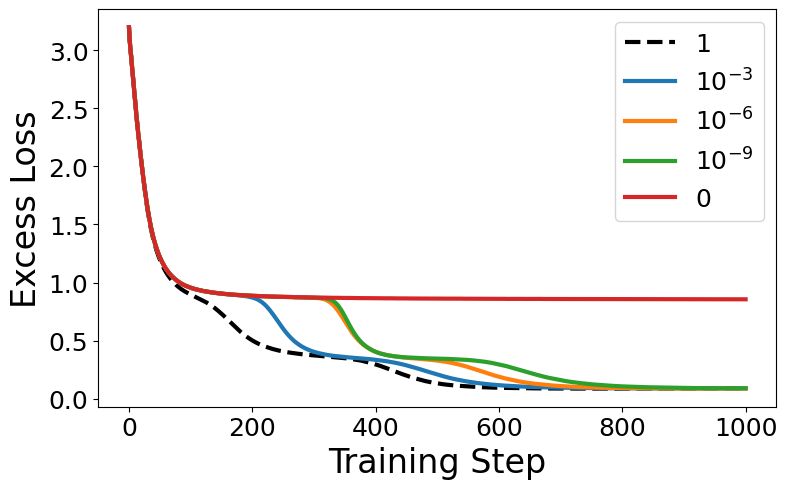

In [3]:
teacher_val_loss = df["teacher_val_loss"].dropna().unique()[0]
max_step = 1000

fig, ax = plt.subplots(figsize=(8, 5))
groups = {
    scale: data.sort_values("_step")
    for (_, scale), data in df.groupby(["_run_name", "cfg.student.query_init_scale"], dropna=False)
}


def get_group(scale):
    for group_scale, data in groups.items():
        if pd.isna(scale) and pd.isna(group_scale):
            return data
        if not pd.isna(scale) and not pd.isna(group_scale) and float(group_scale) == scale:
            return data
    raise KeyError(scale)

styles = [
    (np.nan, "1", "black", "--"),
    (1e-3, r"$10^{-3}$", REPORT_BLUE, "-"),
    (1e-6, r"$10^{-6}$", REPORT_YELLOW, "-"),
    (1e-9, r"$10^{-9}$", REPORT_GREEN, "-"),
    (0.0, "0", REPORT_RED, "-"),
]

for scale, label, color, linestyle in styles:
    data = get_group(scale).copy()
    data["relative_step"] = data["_step"] - data["_step"].min()
    data = data[data["relative_step"] <= max_step]
    y = data["val_loss"].to_numpy() - teacher_val_loss
    ax.plot(
        data["relative_step"],
        y,
        label=label,
        color=color,
        linestyle=linestyle,
        linewidth=REPORT_LINEWIDTH,
    )

style_report_axis(ax, xlabel="Training Step", ylabel="Excess Loss", legend=True)
plt.tight_layout()

if SAVE_FIGURES:
    fig.savefig(output_path("init-scales-excess-loss.pdf"), bbox_inches="tight", dpi=300)
else:
    plt.show()
